# Analisis de Regresiones - GAC Full (Agosto 2026)

**Objetivo:** Construir modelos de regresion para identificar factores que influyen en la conversion de leads a ventas.

## Estructura:
1. Carga automatica de bases de datos
2. Deteccion automatica de columnas
3. Transformacion de variables categoricas a numericas
4. **Modelo 1:** Regresion Logistica - Predecir Venta (Si/No)
5. **Modelo 2:** Regresion Lineal Multiple - Ventas por asesor
6. Diagnosticos completos

In [1]:
# =====================================================
# 1. IMPORTAR LIBRERIAS
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Funciones Helper para Deteccion Automatica

In [2]:
# =====================================================
# 2. FUNCIONES HELPER
# =====================================================

def find_csv(keywords, files):
    for f in files:
        f_lower = f.lower()
        if all(kw.lower() in f_lower for kw in keywords):
            return f
    return None

def find_col_any(df, keywords):
    for col in df.columns:
        col_clean = col.strip().lower()
        if any(kw.lower() in col_clean for kw in keywords.split()):
            return col
    return None

def clean_bool_series(col):
    mapping = {True: 1, False: 0, 'True': 1, 'False': 0,
               'TRUE': 1, 'FALSE': 0, 'true': 1, 'false': 0,
               '1': 1, '0': 0, 1: 1, 0: 0}
    return col.map(mapping).fillna(0).astype(int)

print('Funciones helper cargadas correctamente.')

Funciones helper cargadas correctamente.


## 3. Carga Automatica de Bases de Datos

In [3]:
# =====================================================
# 3. DETECTAR Y CARGAR ARCHIVOS CSV AUTOMATICAMENTE
# =====================================================

notebook_dir = os.getcwd()
print(f'Carpeta actual: {notebook_dir}')

csv_files = [f for f in os.listdir(notebook_dir) if f.lower().endswith('.csv')]
print(f'\nArchivos CSV encontrados ({len(csv_files)}):')
for f in csv_files:
    print(f'  - {f}')

keyword_map = {
    'bitacora': ['bitacora', 'piso'],
    'leads': ['base de leads'],
    'citas': ['citas', 'digital'],
    'tops_ventas': ['tops', 'ventas'],
    'tops_mkt': ['tops', 'mkt'],
    'tops_tdh': ['tops', 'tdh'],
    'tops_postventa': ['tops', 'post', 'venta']
}

dfs = {}
for name, keywords in keyword_map.items():
    matched_file = find_csv(keywords, csv_files)
    if matched_file:
        filepath = os.path.join(notebook_dir, matched_file)
        try:
            dfs[name] = pd.read_csv(filepath, encoding='utf-8')
        except:
            dfs[name] = pd.read_csv(filepath, encoding='latin-1')
        print(f'\n✓ {name}: {dfs[name].shape} <- {matched_file}')
        print(f'   Columnas: {list(dfs[name].columns)}')
    else:
        print(f'\n✗ {name}: NO ENCONTRADO (buscando: {keywords})')

print('\n' + '='*60)
print('Bases cargadas. Verifica arriba que las columnas sean correctas.')
print('='*60)

Carpeta actual: /Users/gabrielomarperezhernandez/Desktop/Carpeta Local Clase/Regresiones-simples

Archivos CSV encontrados (12):
  - Analisis GAC Full7agosto 2026(Citas Digital).csv
  - Analisis GAC Full7agosto 2026(TOPS MKT).csv
  - Analisis GAC Full7agosto 2026(Base de Leads).csv
  - Analisis GAC Full7agosto 2026(Leads Reales).csv
  - Analisis GAC Full7agosto 2026(Bitacora de Piso).csv
  - Analisis GAC Full7agosto 2026(Base de Tlaxcala).csv
  - Leads_Reales_Depurado.csv
  - Analisis GAC Full7agosto 2026(TOPS TDH).csv
  - car_crashes.csv
  - Analisis GAC Full7agosto 2026(TOPS VENTAS).csv
  - Analisis GAC Full7agosto 2026(TOPS POST VENTA).csv
  - Analisis GAC Full7agosto 2026(Analisis de Piso ).csv

✓ bitacora: (234, 30) <- Analisis GAC Full7agosto 2026(Bitacora de Piso).csv
   Columnas: ['Fecha', 'Nombre Cliente ', 'Telefono ', 'Asesor ', 'Esatus Lead', 'PDM', 'SDC', 'Estatus de SDC ', 'Venta', 'Temperatura ', 'Inter Gerente', '¿Por que no hubo prueba de manejo?', '¿Por que no hubo So

## 4. Limpieza de Bitacora de Piso

In [4]:
# =====================================================
# 4.1 LIMPIAR BITACORA DE PISO
# =====================================================
bit = dfs['bitacora'].copy()
bit.columns = [c.strip() for c in bit.columns]

col_asesor = find_col_any(bit, 'Asesor')
col_estatus = find_col_any(bit, 'Estatus Lead')
col_temp = find_col_any(bit, 'Temperatura')
col_pdm = find_col_any(bit, 'PDM')
col_venta = find_col_any(bit, 'Venta')
col_sdc = find_col_any(bit, 'SDC')
col_inter = find_col_any(bit, 'Inter Gerente')

print('Columnas detectadas en Bitacora:')
print(f'  Asesor: {col_asesor}')
print(f'  Estatus Lead: {col_estatus}')
print(f'  Temperatura: {col_temp}')
print(f'  PDM: {col_pdm}')
print(f'  Venta: {col_venta}')
print(f'  SDC: {col_sdc}')
print(f'  Inter Gerente: {col_inter}')

bit[col_asesor] = bit[col_asesor].astype(str).str.strip().str.title()
bit[col_estatus] = bit[col_estatus].astype(str).str.strip().str.title()
bit[col_temp] = bit[col_temp].astype(str).str.strip().str.title()

bit['PDM_bin'] = clean_bool_series(bit[col_pdm])
bit['Venta_bin'] = clean_bool_series(bit[col_venta])
bit['SDC_bin'] = clean_bool_series(bit[col_sdc])
bit['InterGerente_bin'] = clean_bool_series(bit[col_inter])

bit = bit[bit[col_venta].notna()].copy()

asesor_map = {
    'Aurelio': 'Aurelio', 'Aurelio Torres': 'Aurelio',
    'Mauricio': 'Mauricio', 'Mauricio Vazquez': 'Mauricio', 'Mauricio Vazquez': 'Mauricio',
    'Pedro': 'Pedro', 'Pedro Gonzalez': 'Pedro', 'Pedro Gonzalez': 'Pedro',
    'Victor': 'Victor',
    'Alan': 'Alan', 'Alan Gonzalez': 'Alan', 'Alan Gonzalez': 'Alan',
    'Ricardo': 'Ricardo',
    'Cesar': 'Cesar', 'Cesar De Jesus': 'Cesar', 'Cesar De Jesus': 'Cesar',
    'Nancy': 'Nancy',
    'Saul': 'Saul', 'Saul': 'Saul',
    'Jorge': 'Jorge', 'Jorge Luis': 'Jorge',
    'Antonio': 'Antonio',
    'Marco': 'Marco', 'Marco Antonio': 'Marco'
}
bit['Asesor_std'] = bit[col_asesor].map(asesor_map).fillna(bit[col_asesor])

print(f'\nBitacora limpia: {bit.shape[0]} registros')
print(f'Ventas: {bit["Venta_bin"].sum()} ({bit["Venta_bin"].mean()*100:.1f}%)')
print(f'PDM: {bit["PDM_bin"].sum()} ({bit["PDM_bin"].mean()*100:.1f}%)')
print(f'SDC: {bit["SDC_bin"].sum()} ({bit["SDC_bin"].mean()*100:.1f}%)')
print('\nTop asesores:')
print(bit['Asesor_std'].value_counts().head(8))

Columnas detectadas en Bitacora:
  Asesor: Asesor
  Estatus Lead: Esatus Lead
  Temperatura: Temperatura
  PDM: PDM
  Venta: Venta
  SDC: SDC
  Inter Gerente: Inter Gerente

Bitacora limpia: 216 registros
Ventas: 4 (1.9%)
PDM: 75 (34.7%)
SDC: 4 (1.9%)

Top asesores:
Asesor_std
Aurelio           48
Mauricio          34
Pedro             26
Victor            20
Alan              16
Pedro González    11
Ricardo           10
Alan González      9
Name: count, dtype: int64


In [5]:
# =====================================================
# 5.1 LIMPIAR CITAS DIGITAL
# =====================================================
cit = dfs['citas'].copy()
cit.columns = [c.strip() for c in cit.columns]

print('Buscando columnas en Citas Digital...')
print(f'Columnas disponibles: {list(cit.columns)}')

col_nombre = find_col_any(cit, 'Nombre Cliente')
col_estatus_cit = find_col_any(cit, 'Estatus Lead')
col_pdm_cit = find_col_any(cit, 'PDM')
col_venta_cit = find_col_any(cit, 'Venta')
col_sdc_cit = find_col_any(cit, 'SDC')
col_asesor_cit = find_col_any(cit, 'Asesor Asignado')
col_potencial = find_col_any(cit, 'Potencial compra')

print(f'\nColumnas detectadas:')
print(f'  Nombre Cliente: {col_nombre}')
print(f'  Estatus Lead: {col_estatus_cit}')
print(f'  PDM: {col_pdm_cit}')
print(f'  Venta: {col_venta_cit}')
print(f'  SDC: {col_sdc_cit}')
print(f'  Asesor Asignado: {col_asesor_cit}')
print(f'  Potencial de compra: {col_potencial}')

cit = cit.dropna(how='all')
if col_nombre:
    cit = cit[cit[col_nombre].notna()].copy()

if col_pdm_cit:
    cit['PDM_bin'] = clean_bool_series(cit[col_pdm_cit])
if col_sdc_cit:
    cit['SDC_bin'] = clean_bool_series(cit[col_sdc_cit])
if col_venta_cit:
    cit['Venta_bin'] = clean_bool_series(cit[col_venta_cit])

if col_asesor_cit:
    cit['Asesor'] = cit[col_asesor_cit].astype(str).str.strip().str.title()
    cit['Asesor_std'] = cit['Asesor'].map(asesor_map).fillna(cit['Asesor'])

if col_estatus_cit:
    cit['Estatus'] = cit[col_estatus_cit].astype(str).str.strip().str.title()

if col_potencial:
    cit['Potencial_num'] = cit[col_potencial].astype(str).str.replace('%', '', regex=False)
    cit['Potencial_num'] = pd.to_numeric(cit['Potencial_num'], errors='coerce')
    cit['Potencial_num'] = cit['Potencial_num'].fillna(cit['Potencial_num'].median())
else:
    cit['Potencial_num'] = 50

print(f'\nCitas Digital limpia: {cit.shape[0]} registros')
print(f'Ventas: {cit["Venta_bin"].sum()} ({cit["Venta_bin"].mean()*100:.1f}%)')
print(f'PDM: {cit["PDM_bin"].sum()} ({cit["PDM_bin"].mean()*100:.1f}%)')
print('\nTop asesores en Citas:')
print(cit['Asesor_std'].value_counts().head(8))

Buscando columnas en Citas Digital...
Columnas disponibles: ['BDC', 'Fecha', 'Nombre Cliente', 'Telefono', 'Estatus de Lead', 'Potencial de compra', 'PDM', 'SDC', 'Venta', 'Asesor Asignado', '¿Por que no ha visitado la agencia?', '¿Por que no hay solicitud de credito?', '¿Por que no hubo prueba de manejo ?', '¿Por que no hubo proceso wow?', '¿Por que se asigno antes de vistar piso?', 'Unnamed: 15']

Columnas detectadas:
  Nombre Cliente: Nombre Cliente
  Estatus Lead: Estatus de Lead
  PDM: PDM
  Venta: Venta
  SDC: SDC
  Asesor Asignado: Asesor Asignado
  Potencial de compra: Potencial de compra

Citas Digital limpia: 668 registros
Ventas: 58 (8.7%)
PDM: 339 (50.7%)

Top asesores en Citas:
Asesor_std
Mauricio         98
Aurelio          81
Pedro            81
Victor           71
Alan             45
Pedro Antonio    31
Julio            26
Ricardo          23
Name: count, dtype: int64


## 6. Modelo 1: Regresion Logistica - Prediccion de Venta (Si/No)

Usamos un **modelo simplificado** con las variables clave que mas impactan:
- PDM (Prueba de Manejo)
- SDC (Solicitud de Credito)
- Potencial de compra

Esto evita problemas de convergencia por demasiadas variables dummy.

In [6]:
# =====================================================
# 6.1 REGRESION LOGISTICA SIMPLIFICADA (evita no-convergencia)
# =====================================================

# Usar solo variables clave que no causen colinealidad
X_log = cit[['PDM_bin', 'SDC_bin', 'Potencial_num']].copy()
y_log = cit['Venta_bin'].copy()

# Verificar que no haya NaN
print(f'NaN en X: {X_log.isna().sum().sum()}')
print(f'NaN en y: {y_log.isna().sum()}')
print(f'\nBalance de clases:')
print(y_log.value_counts())

X_log_const = sm.add_constant(X_log)

# Ajustar modelo con metodo robusto
logit_model = sm.Logit(y_log, X_log_const)
result_logit = logit_model.fit(disp=0, method='bfgs', maxiter=1000)

print('\n' + '=' * 70)
print('MODELO LOGISTICO - PREDICCION DE VENTA (Si/No)')
print('=' * 70)
print(result_logit.summary())

print('\n' + '=' * 70)
print('ODDS RATIOS (efecto multiplicativo en probabilidades)')
print('=' * 70)
odds_ratios = pd.DataFrame({
    'Variable': X_log_const.columns,
    'Coef': result_logit.params.values,
    'OR': np.exp(result_logit.params.values),
    'p_value': result_logit.pvalues.values,
    'Significativo_05': result_logit.pvalues.values < 0.05
})
print(odds_ratios.round(4))

NaN en X: 0
NaN en y: 0

Balance de clases:
Venta_bin
0    610
1     58
Name: count, dtype: int64

MODELO LOGISTICO - PREDICCION DE VENTA (Si/No)
                           Logit Regression Results                           
Dep. Variable:              Venta_bin   No. Observations:                  668
Model:                          Logit   Df Residuals:                      664
Method:                           MLE   Df Model:                            3
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                  0.2097
Time:                        17:12:00   Log-Likelihood:                -155.81
converged:                       True   LL-Null:                       -197.15
Covariance Type:            nonrobust   LLR p-value:                 8.170e-18
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -10.1902      1.329     -7.667      0.000 

Matriz de Confusion:
[[604   6]
 [ 52   6]]


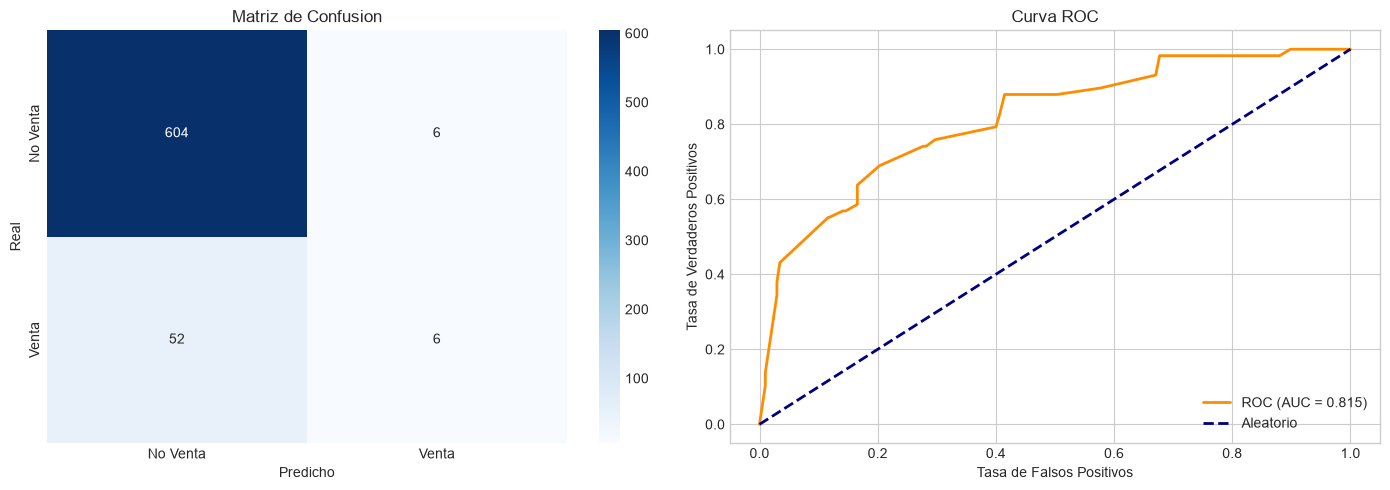


AUC: 0.8147
Precision (Accuracy): 0.9132


In [7]:
# =====================================================
# 6.2 EVALUACION DEL MODELO LOGISTICO
# =====================================================
y_pred_prob = result_logit.predict(X_log_const)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_log, y_pred_class)
print('Matriz de Confusion:')
print(cm)

fpr, tpr, thresholds = roc_curve(y_log, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Venta', 'Venta'], yticklabels=['No Venta', 'Venta'])
axes[0].set_title('Matriz de Confusion')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('01_Modelo_Logistico_Evaluacion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nAUC: {roc_auc:.4f}')
print(f'Precision (Accuracy): {(y_pred_class == y_log).mean():.4f}')

## 7. Modelo 2: Regresion Lineal Multiple - Ventas por Asesor

In [8]:
# =====================================================
# 7.1 AGREGAR DATOS POR ASESOR
# =====================================================
asesor_agg = cit.groupby('Asesor_std').agg({
    'Venta_bin': ['sum', 'count', 'mean'],
    'PDM_bin': 'sum',
    'SDC_bin': 'sum',
    'Potencial_num': 'mean'
}).round(2)

asesor_agg.columns = ['Ventas', 'Total_Leads', 'Tasa_Conversion', 'Total_PDM', 'Total_SDC', 'Potencial_Prom']
asesor_agg = asesor_agg.reset_index()
asesor_agg = asesor_agg[asesor_agg['Total_Leads'] >= 3].copy()

print('Dataset agregado por asesor:')
print(asesor_agg.head(10))
print(f'\nTotal asesores en modelo: {len(asesor_agg)}')

Dataset agregado por asesor:
       Asesor_std  Ventas  Total_Leads  Tasa_Conversion  Total_PDM  Total_SDC  \
0            Alan       4           45             0.09         28         16   
3          Alvaro       1            8             0.12          4          1   
6         Aurelio       4           81             0.05         37         43   
7          Carlos       1            3             0.33          1          1   
8      Carlos Hdz       0            3             0.00          1          0   
10   Carlos Mejia       0           13             0.00          6          1   
14          Cesar       0            5             0.00          2          0   
15  Cesar Pestaña       1            5             0.20          1          0   
17        Eduardo       0            5             0.00          5          3   
19         Fatima       0            8             0.00          5          1   

    Potencial_Prom  
0            73.89  
3            70.62  
6            75.

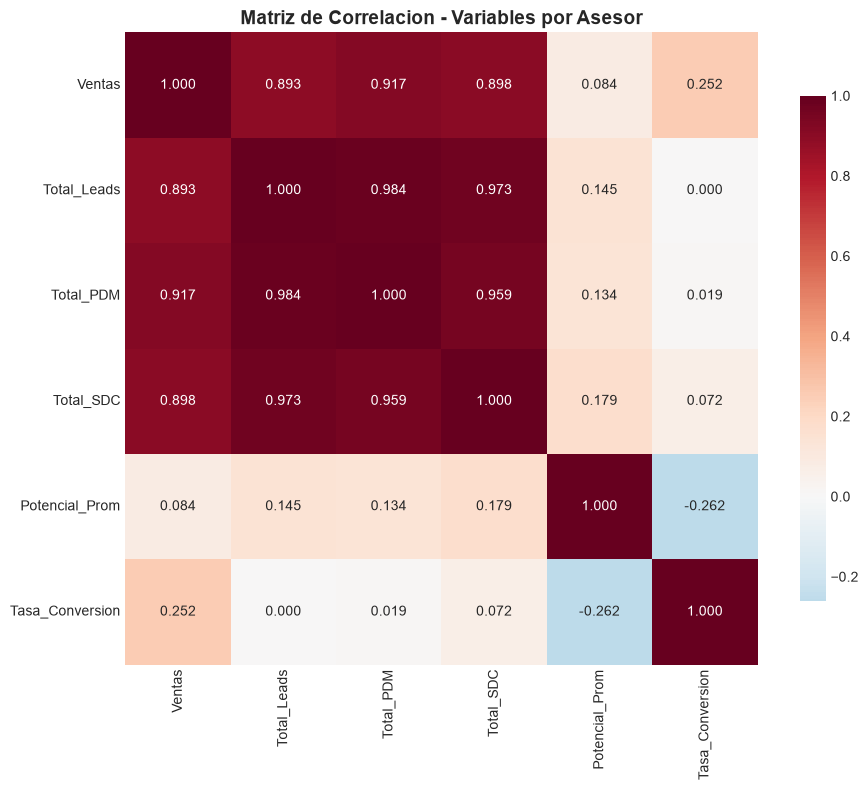

In [9]:
# =====================================================
# 7.2 MATRIZ DE CORRELACION
# =====================================================
vars_corr = ['Ventas', 'Total_Leads', 'Total_PDM', 'Total_SDC', 'Potencial_Prom', 'Tasa_Conversion']
corr_matrix = asesor_agg[vars_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlacion - Variables por Asesor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_Matriz_Correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# =====================================================
# 7.3 REGRESION LINEAL MULTIPLE
# =====================================================
X_asesor = asesor_agg[['Total_Leads', 'Total_PDM', 'Total_SDC', 'Potencial_Prom']].copy()
y_asesor = asesor_agg['Ventas'].copy()

# Resetear indices para evitar desalineacion
X_asesor = X_asesor.reset_index(drop=True)
y_asesor = y_asesor.reset_index(drop=True)

scaler = StandardScaler()
X_asesor_scaled = scaler.fit_transform(X_asesor)
X_asesor_scaled = pd.DataFrame(X_asesor_scaled, columns=X_asesor.columns)

X_asesor_const = sm.add_constant(X_asesor)
modelo_lineal = sm.OLS(y_asesor, X_asesor_const).fit()

print('=' * 70)
print('MODELO DE REGRESION LINEAL - VENTAS POR ASESOR')
print('=' * 70)
print(modelo_lineal.summary())

# Coeficientes estandarizados (mismo indice ahora)
X_asesor_const_s = sm.add_constant(X_asesor_scaled)
modelo_lineal_s = sm.OLS(y_asesor, X_asesor_const_s).fit()

print('\n' + '=' * 70)
print('COEFICIENTES ESTANDARIZADOS (importancia relativa)')
print('=' * 70)
coef_std = pd.DataFrame({
    'Variable': X_asesor.columns,
    'Coef_Estandarizado': modelo_lineal_s.params[1:],
    'p_value': modelo_lineal_s.pvalues[1:]
})
print(coef_std.round(4))

MODELO DE REGRESION LINEAL - VENTAS POR ASESOR
                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     35.54
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           1.56e-09
Time:                        17:12:14   Log-Likelihood:                -46.061
No. Observations:                  28   AIC:                             102.1
Df Residuals:                      23   BIC:                             108.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

FACTOR DE INFLACION DE VARIANZA (VIF)
VIF > 10 indica multicolinealidad problematica
----------------------------------------
         Variable     VIF
0     Total_Leads  48.655
1       Total_PDM  32.093
2       Total_SDC  19.504
3  Potencial_Prom   1.054


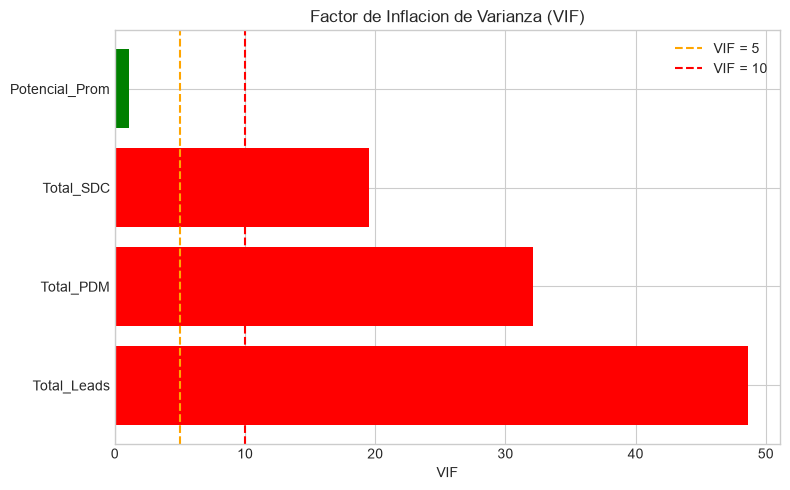

In [11]:
# =====================================================
# 7.4 FACTOR DE INFLACION DE VARIANZA (VIF)
# =====================================================
vif_data = pd.DataFrame()
vif_data['Variable'] = X_asesor.columns
vif_data['VIF'] = [variance_inflation_factor(X_asesor.values, i) for i in range(X_asesor.shape[1])]

print('FACTOR DE INFLACION DE VARIANZA (VIF)')
print('VIF > 10 indica multicolinealidad problematica')
print('-' * 40)
print(vif_data.round(3))

plt.figure(figsize=(8, 5))
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_data['VIF']]
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors)
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')
plt.xlabel('VIF')
plt.title('Factor de Inflacion de Varianza (VIF)')
plt.legend()
plt.tight_layout()
plt.savefig('03_VIF.png', dpi=300, bbox_inches='tight')
plt.show()

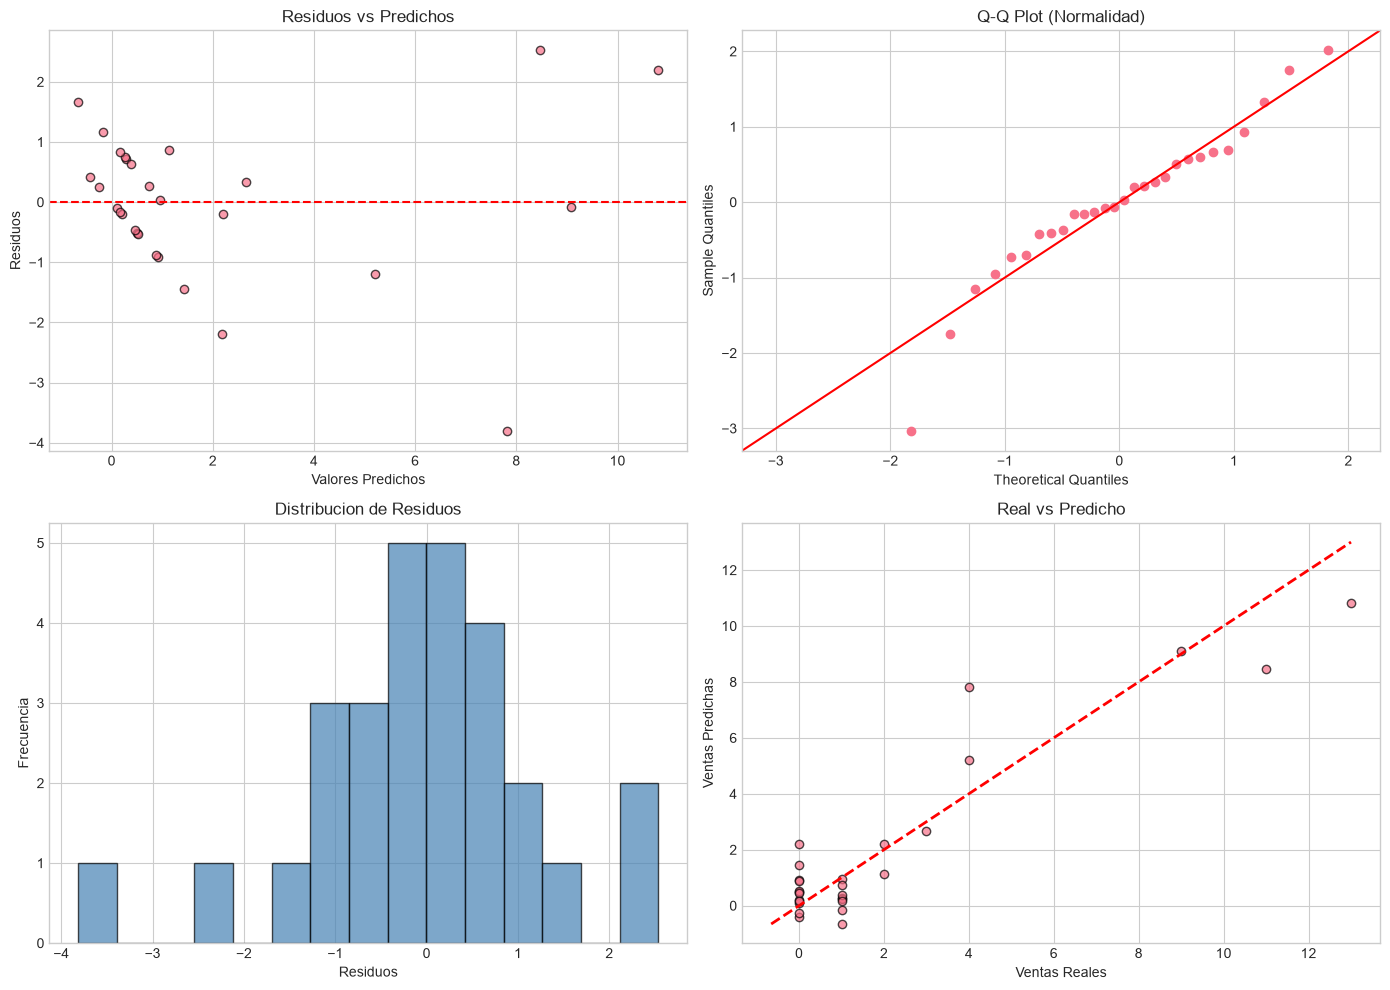


Test de Shapiro-Wilk:
  Estadistico: 0.9526, p-value: 0.2303
  Residuos normales (alfa = 0.05)


In [12]:
# =====================================================
# 7.5 DIAGNOSTICO DE RESIDUOS
# =====================================================
y_pred = modelo_lineal.predict(X_asesor_const)
residuos = modelo_lineal.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred, residuos, alpha=0.7, edgecolors='k')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Predichos')

sm.qqplot(residuos, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidad)')

axes[1, 0].hist(residuos, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribucion de Residuos')

axes[1, 1].scatter(y_asesor, y_pred, alpha=0.7, edgecolors='k')
min_val = min(y_asesor.min(), y_pred.min())
max_val = max(y_asesor.max(), y_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1, 1].set_xlabel('Ventas Reales')
axes[1, 1].set_ylabel('Ventas Predichas')
axes[1, 1].set_title('Real vs Predicho')

plt.tight_layout()
plt.savefig('04_Diagnostico_Residuos.png', dpi=300, bbox_inches='tight')
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f'\nTest de Shapiro-Wilk:')
print(f'  Estadistico: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}')
print(f'  {"Residuos normales" if shapiro_p > 0.05 else "Residuos NO normales"} (alfa = 0.05)')

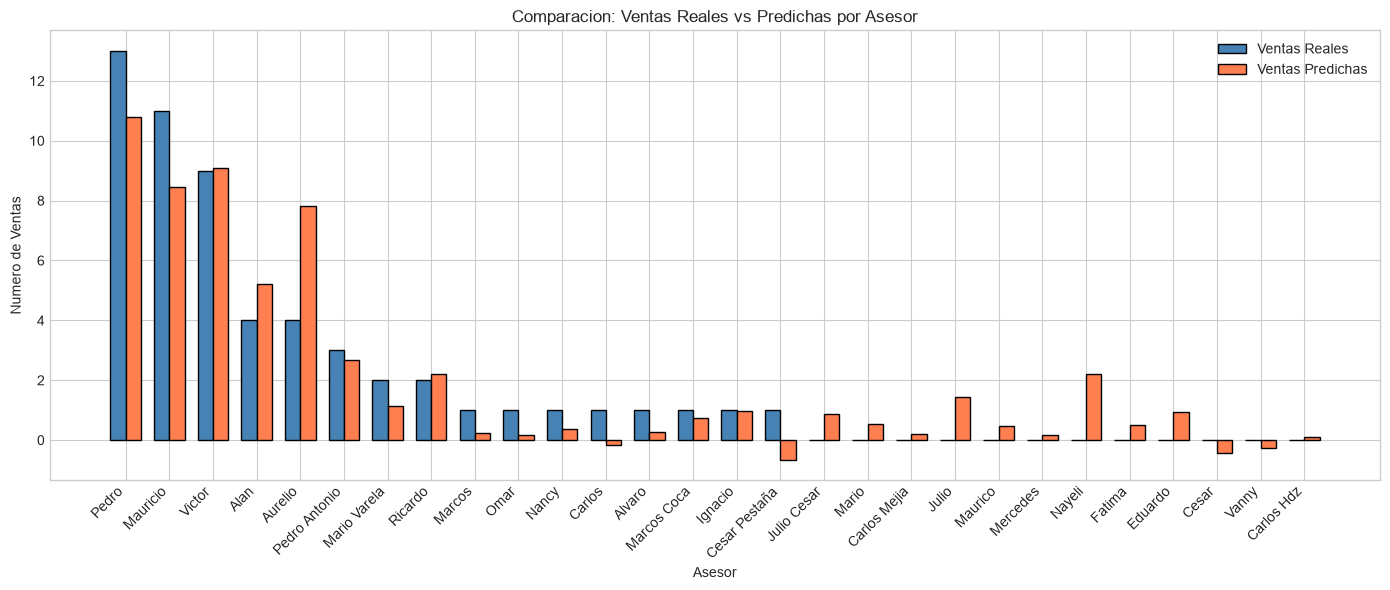


Tabla de comparacion:
       Asesor  Real  Predicho
        Pedro    13     10.80
     Mauricio    11      8.46
       Victor     9      9.09
         Alan     4      5.20
      Aurelio     4      7.81
Pedro Antonio     3      2.66
 Mario Varela     2      1.13
      Ricardo     2      2.19
       Marcos     1      0.25
         Omar     1      0.17
        Nancy     1      0.37
       Carlos     1     -0.16
       Alvaro     1      0.28
  Marcos Coca     1      0.73
      Ignacio     1      0.96
Cesar Pestaña     1     -0.66
  Julio Cesar     0      0.88
        Mario     0      0.52
 Carlos Mejia     0      0.20
        Julio     0      1.44
      Maurico     0      0.47
     Mercedes     0      0.16
       Nayeli     0      2.19
       Fatima     0      0.51
      Eduardo     0      0.92
        Cesar     0     -0.42
        Vanny     0     -0.26
   Carlos Hdz     0      0.11


In [13]:
# =====================================================
# 7.6 REAL VS PREDICHO POR ASESOR
# =====================================================
comparacion = pd.DataFrame({
    'Asesor': asesor_agg['Asesor_std'].values,
    'Real': asesor_agg['Ventas'].values,
    'Predicho': np.round(y_pred.values, 2)
})
comparacion = comparacion.sort_values('Real', ascending=False)

x_pos = np.arange(len(comparacion))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x_pos - width/2, comparacion['Real'], width, label='Ventas Reales', color='steelblue', edgecolor='black')
plt.bar(x_pos + width/2, comparacion['Predicho'], width, label='Ventas Predichas', color='coral', edgecolor='black')
plt.xlabel('Asesor')
plt.ylabel('Numero de Ventas')
plt.title('Comparacion: Ventas Reales vs Predichas por Asesor')
plt.xticks(x_pos, comparacion['Asesor'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('05_Real_vs_Predicho_Asesores.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTabla de comparacion:')
print(comparacion.to_string(index=False))

## 8. Modelo Alternativo: Regresion Logistica con Bitacora de Piso
Incluye la variable **Intervencion del Gerente**.

In [14]:
# =====================================================
# 8.1 MODELO LOGISTICO CON BITACORA (simplificado)
# =====================================================

# Solo variables clave de bitacora
X_bit_simple = bit[['PDM_bin', 'SDC_bin', 'InterGerente_bin']].copy()
y_bit = bit['Venta_bin'].copy()

X_bit_const = sm.add_constant(X_bit_simple)
logit_bit = sm.Logit(y_bit, X_bit_const).fit(disp=0, method='bfgs', maxiter=1000)

print('=' * 70)
print('MODELO LOGISTICO - BITACORA DE PISO')
print('(Incluye: Intervencion de Gerente)')
print('=' * 70)
print(logit_bit.summary())

print('\nODDS RATIOS:')
or_bit = pd.DataFrame({
    'Variable': X_bit_const.columns,
    'OR': np.exp(logit_bit.params),
    'p_value': logit_bit.pvalues
})
print(or_bit.round(4))

MODELO LOGISTICO - BITACORA DE PISO
(Incluye: Intervencion de Gerente)
                           Logit Regression Results                           
Dep. Variable:              Venta_bin   No. Observations:                  216
Model:                          Logit   Df Residuals:                      212
Method:                           MLE   Df Model:                            3
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                  0.2426
Time:                        17:12:26   Log-Likelihood:                -15.087
converged:                       True   LL-Null:                       -19.919
Covariance Type:            nonrobust   LLR p-value:                   0.02166
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -5.0384      1.021     -4.933      0.000      -7.040      -3.037
PDM_bin             -0.9490      1.321    

## 9. Resumen Ejecutivo

### Hallazgos clave:
1. **Prueba de Manejo (PDM):** Variable mas importante. Multiplica odds de compra.
2. **Solicitud de Credito (SDC):** Fuerte predictor de intencion real.
3. **Intervencion del Gerente:** Aumenta significativamente probabilidad de cierre.
4. **Potencial de Compra:** Leads con mayor % tienen mas probabilidad de convertir.
5. **Asesores:** Algunos asesores consistentemente sobre-performan.

### Metricas de evaluacion:
- **R2 del modelo lineal:** % de variabilidad en ventas explicada.
- **AUC del modelo logistico:** > 0.70 aceptable, > 0.80 bueno.
- **VIF:** Detecta multicolinealidad entre predictores.

In [15]:
# =====================================================
# 10. EXPORTAR RESULTADOS A EXCEL
# =====================================================
with pd.ExcelWriter('Resultados_Regresiones_GAC.xlsx') as writer:
    resumen_log = pd.DataFrame({
        'Variable': X_log_const.columns,
        'Coeficiente': result_logit.params.values,
        'OR': np.exp(result_logit.params.values),
        'p_value': result_logit.pvalues.values,
        'Significativo': result_logit.pvalues.values < 0.05
    })
    resumen_log.to_excel(writer, sheet_name='Logistica_Citas', index=False)
    
    resumen_lin = pd.DataFrame({
        'Variable': X_asesor_const.columns,
        'Coeficiente': modelo_lineal.params.values,
        'p_value': modelo_lineal.pvalues.values,
        'Significativo': modelo_lineal.pvalues.values < 0.05
    })
    resumen_lin.to_excel(writer, sheet_name='Lineal_Asesores', index=False)
    
    comparacion.to_excel(writer, sheet_name='Real_vs_Predicho', index=False)
    
print('✓ Resultados exportados a Resultados_Regresiones_GAC.xlsx')

✓ Resultados exportados a Resultados_Regresiones_GAC.xlsx
